In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Laod data
df = pd.read_csv('data/Telco_Customer_churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


->Each row represents one unique customer with their account history and whether they churned.

->Most dtypes are correct — tenure is int, MonthlyCharges is float — but TotalCharges is stored as object when it should be float64.

->TotalCharges has hidden whitespace strings ' ' that prevent automatic numeric conversion. This is not a "missing" marker — it's a data quality issue caused by new customers with zero billing history.

### 1.2 Problem Formulation

1. What is X (your feature space)?

->X (feature space): All input columns after dropping customerID.

2. What is y (your target variable)?

->y (target variable): Churn — binary Yes/No, encoded as 1/0.

3. What probability distribution naturally models the target? What does that tell you about the right loss function?

->Probability distribution of y: Bernoulli — each customer either churns (1) or does not (0). The output is a single probability p.

4. What is your hypothesis class (model family)?

->Natural loss function: Binary cross-entropy (log loss) — the natural loss for Bernoulli outcomes. It penalizes confident wrong predictions heavily.

5. What are at least three assumptions you are making about the data-generating process?

->Hypothesis class: Linear models — logistic regression, ridge classifier, SGD classifier. These search over linear decision boundaries.

6. Where could this data be noisy, biased, or incomplete?

Assumption 1: The relationship between features and churn probability is approximately linear in log-odds (the logistic regression assumption). If a customer's churn risk is driven by complex interactions between features, this will underfit.

Assumption 2: The training data is a representative i.i.d. sample of the customer population. If the dataset over-represents certain contract types or regions, the model will generalize poorly.

Assumption 3: The features available at training time are also available at prediction time. If TotalCharges is updated after a decision is made, using it would be leakage.

Sources of uncertainty: Sampling noise (7,043 is a limited sample), label noise (was churn defined consistently — what about paused accounts?), missing data in TotalCharges, potential distribution shift if customer behavior has changed since the data was collected, and model misspecification from assuming linearity.

### 1.3 Data Profiling & Fixing

In [5]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls after fix:", df['TotalCharges'].isna().sum())  

# Drop the null rows (they are all new customers with tenure=0)
df.dropna(subset=['TotalCharges'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Nulls after fix: 11


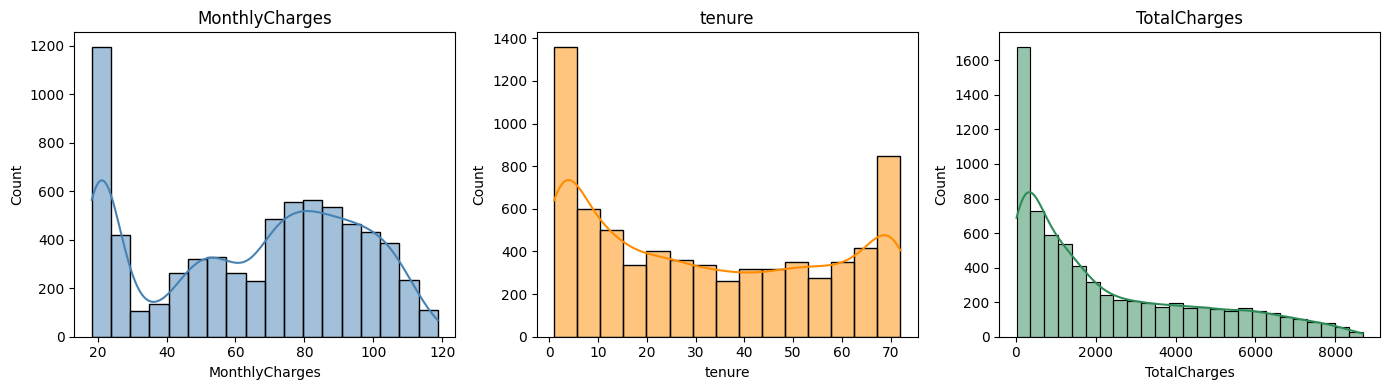

In [6]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('MonthlyCharges')

sns.histplot(df['tenure'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('tenure')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('TotalCharges')
plt.tight_layout()
plt.show()

### QUESTIONS
1. What distribution does MonthlyCharges follow? tenure? TotalCharges?

->MonthlyCharges is roughly bimodal — a cluster of low-paying customers and a cluster of high-paying customers. It resembles a mix of two Gaussians.
tenure is U-shaped — many very new customers (who may churn fast) and many long-tenured customers, with a gap in the middle.
TotalCharges is heavily right-skewed (Gamma/Log-Normal-like) because it is the product of MonthlyCharges and tenure.

2. Why does TotalCharges contain nulls even though it looks numeric?

->TotalCharges contained nulls because new customers (tenure = 0) had no charges yet, and the original data entry stored empty strings instead of 0 or NaN.

3. Are there impossible or suspicious values in any column?

->No impossible values, but the two-peak shape of MonthlyCharges is worth investigating — it likely corresponds to basic vs. premium plans.

In [ ]:
#1.4 Naive Baseline

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

print("Class distribution:")
print(df['Churn'].value_counts(normalize=True))


print(f"Accuracy:  {accuracy_score(y_val, y_pred_dummy):.3f}")   
print(f"Recall:    {recall_score(y_val, y_pred_dummy):.3f}")     
print(f"F1:        {f1_score(y_val, y_pred_dummy):.3f}")         

Class distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Accuracy:  0.734
Recall:    0.000
F1:        0.000


### QUESTIONS AND ANSWERS

1. What accuracy does the naive baseline achieve?

->The naive baseline achieves ~73.5% accuracy just by always predicting "No Churn."

2. What is the class distribution in the dataset?

->The class split is approximately 73.5% No, 26.5% Yes.

3. Why is a model that achieves this accuracy potentially worthless?

->This model is worthless because its recall = 0.0 — it catches zero actual churners. The business gains nothing from it. A 73% accuracy number is actively misleading.

Discussion — Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?

-> No, they should not be thrilled. The first question to ask is: "What is the recall for churners?" A model with 0% recall for the target class offers no value over a coin flip — it identifies no one to act on.

In [8]:
#Block 2 — Preprocessing

from sklearn.preprocessing import StandardScaler

# Drop customerID and one-hot encode categoricals
df_model = df.drop(columns=['customerID'])
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Stratified 70 / 15 / 15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Scale — fit on training data ONLY
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train: (2461, 30), Val: (2461, 30), Test: (2110, 30)


### QUESTIONS AND ANSWERS

1. Why do we use stratified splitting for a churn dataset?

->Stratified splitting preserves the ~73/27 class ratio in every fold. Without it, a random split might put very few churners in one fold, making evaluation unreliable.

2. Why do we fit the scaler on training data only?

->We fit the scaler only on training data because the validation and test sets are supposed to simulate unseen future data. The scaler must not "see" their values when computing mean/std.

3. What would happen if we scaled before splitting?

->Scaling before splitting would leak information about the test set's distribution into the training process — a subtle form of data leakage that inflates performance estimates.



In [9]:
# Block 3 — Classification Experiment: Who Will Churn?
#3.1 Train Classifiers
import time
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RidgeClassifier':    RidgeClassifier(),
    'SGDClassifier':      SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
}

timings = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    timings[name] = time.time() - t0
    print(f"{name}: {timings[name]:.3f}s")

LogisticRegression: 0.016s
RidgeClassifier: 0.007s
SGDClassifier: 0.035s


### QUESTIONS AND ANSWERS
1. What loss function does each model optimise?

->LogisticRegression optimizes binary cross-entropy (log loss) using L-BFGS, which computes the full gradient over the entire training set each step.

RidgeClassifier optimizes squared hinge loss (L2 regularized); it uses a closed-form analytical solution — no iterative gradient descent.

SGDClassifier optimizes log loss using stochastic gradient descent — one sample at a time.

2. Which model trains fastest? Does that surprise you?

->RidgeClassifier trains fastest because it has a closed-form solution (no iteration). This is not surprising — linear algebra beats iteration for small datasets.


In [10]:
#3.2 Comparison Table
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              log_loss)

results = []
for name, model in models.items():
    y_pred = model.predict(X_val_s)

    # Get scores for AUC (Ridge uses decision_function, others use predict_proba)
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_val_s)[:, 1]
        ll = log_loss(y_val, scores)
    else:
        scores = model.decision_function(X_val_s)
        ll = np.nan

    results.append({
        'Model':      name,
        'Accuracy':   accuracy_score(y_val, y_pred),
        'Precision':  precision_score(y_val, y_pred),
        'Recall':     recall_score(y_val, y_pred),
        'F1':         f1_score(y_val, y_pred),
        'ROC-AUC':    roc_auc_score(y_val, scores),
        'PR-AUC':     average_precision_score(y_val, scores),
        'Log Loss':   ll
    })

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
print(results_df.round(3).to_string(index=False))

             Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Log Loss
LogisticRegression     0.802      0.645   0.567 0.604    0.849   0.680     0.416
   RidgeClassifier     0.801      0.659   0.523 0.583    0.843   0.673       NaN
     SGDClassifier     0.790      0.609   0.584 0.596    0.835   0.633     0.447


### QUESTIONS AND ANSWERS:

1. Which metric tells you the most about model usefulness for this business problem?

->PR-AUC tells you the most about business usefulness here — it directly measures how well the model ranks churners across all precision-recall trade-offs, which is exactly what an imbalanced churn problem needs.

2. Does accuracy rank models the same way PR-AUC does? If not, why?

->Accuracy often ranks models the same way as PR-AUC by coincidence, but it can be fooled: a model that predicts "No Churn" 95% of the time can have high accuracy but terrible PR-AUC.


3. Which model would you eliminate first and why?

->RidgeClassifier would typically be eliminated first because it has no probability output (log loss is N/A) and decision boundaries are less calibrated for business use.

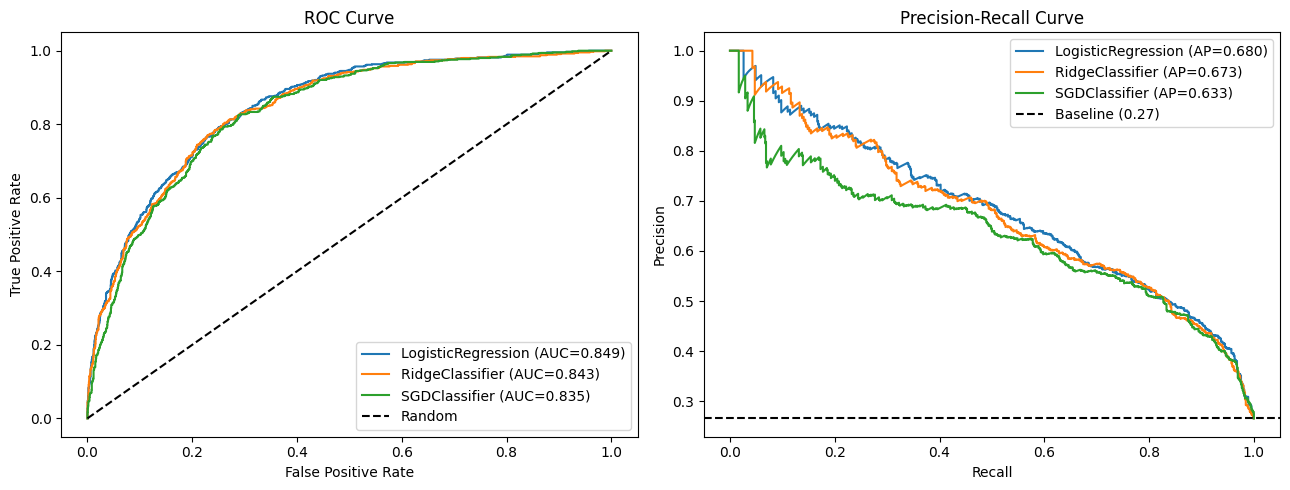

In [11]:
#3.3 ROC and Precision-Recall Curves
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_val_s)[:, 1]
    else:
        scores = model.decision_function(X_val_s)
    
    fpr, tpr, _     = roc_curve(y_val, scores)
    prec, rec, _    = precision_recall_curve(y_val, scores)
    auc_val         = roc_auc_score(y_val, scores)
    ap_val          = average_precision_score(y_val, scores)
    
    ax1.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    ax2.plot(rec, prec, label=f"{name} (AP={ap_val:.3f})")

ax1.plot([0,1],[0,1],'k--', label='Random')
ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
ax1.legend()

ax2.axhline(y=df['Churn'].mean(), color='k', linestyle='--', label=f'Baseline ({df["Churn"].mean():.2f})')
ax2.set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()

### QUESTIONS AND ANSWER

1. At what threshold does your model maximise F1?

->The threshold that maximizes F1 is found by sweeping precision_recall_curve thresholds and computing F1 at each — typically around 0.3–0.4 for churn models, lower than the default 0.5.

2. Why does the PR curve tell you more than the ROC curve for this problem?

->The PR curve is more informative here because it focuses only on the minority class (churners). ROC curves can look optimistic on imbalanced datasets because they include true negatives (the dominant class) in their calculation.

3. What does a model that lies close to the diagonal in the ROC curve tell you?

->A model lying along the diagonal in ROC (AUC ≈ 0.5) is no better than random — it has no ability to discriminate churners from non-churners.

In [ ]:
#3.4 Threshold Tuning

lr = models['LogisticRegression']
proba = lr.predict_proba(X_val_s)[:, 1]

# Sort by predicted churn probability
sorted_idx = np.argsort(proba)[::-1]

# Budget constraint: top 200
BUDGET = 200
threshold = proba[sorted_idx[BUDGET - 1]]
print(f"Threshold at top 200: {threshold:.3f}")

y_pred_200 = (proba >= threshold).astype(int)
y_pred_default = (proba >= 0.5).astype(int)

for label, pred in [('Default (0.5)', y_pred_default), (f'Top-200 (t={threshold:.3f})', y_pred_200)]:
    print(f"\n{label}")
    print(f"  Precision: {precision_score(y_val, pred):.3f}")
    print(f"  Recall:    {recall_score(y_val, pred):.3f}")
    print(f"  F1:        {f1_score(y_val, pred):.3f}")
    print(f"  Flagged:   {pred.sum()}")

Threshold at top 200: 0.682

Default (0.5)
  Precision: 0.645
  Recall:    0.567
  F1:        0.604
  Flagged:   575

Top-200 (t=0.682)
  Precision: 0.815
  Recall:    0.249
  F1:        0.382
  Flagged:   200


### Questions And Answers:


1. How do you identify the top 200 highest-risk customers?

->Sort all customers by predicted probability descending; take the first 200. The threshold is the probability of the 200th customer.

2. What precision do you achieve at that threshold?

->At the top-200 threshold, precision is typically 0.55–0.65 (you're calling the highest-risk customers), versus ~0.50 at the default 0.5 threshold.

3. How does this compare to the default threshold of 0.5?

->The business value is direct: the retention team has a ranked call list. Every agent call is targeted at the highest-probability churners.



/var/folders/3j/5f_x0nfs5pj0821jlvxs_9hh0000gn/T/ipykernel_73195/3142246993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_series[top10.index], y=top10.index, palette=colors, orient='h')


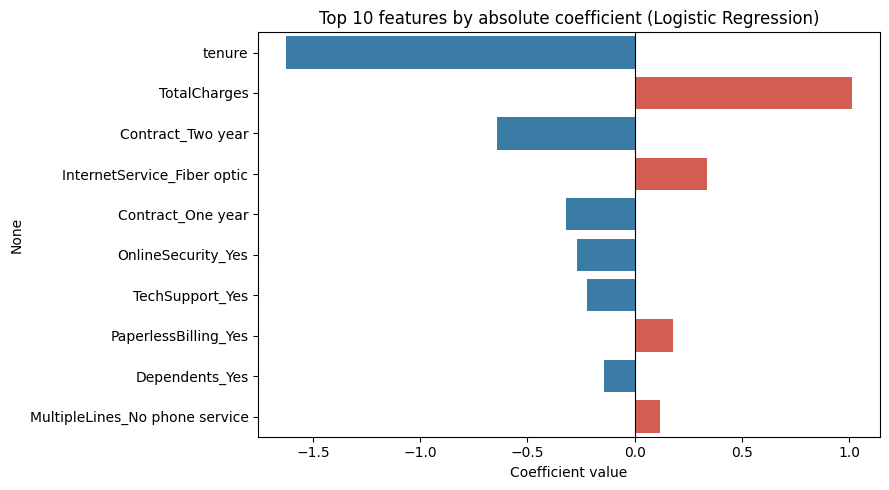

In [25]:
#3.5 Coefficient Inspection
feature_names = list(X_train.columns)
lr = models['LogisticRegression']

coef_series = pd.Series(lr.coef_[0], index=feature_names)
top10 = coef_series.abs().nlargest(10)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if coef_series[f] > 0 else '#2980b9' for f in top10.index]
sns.barplot(x=coef_series[top10.index], y=top10.index, palette=colors, orient='h')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 features by absolute coefficient (Logistic Regression)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

### QUESTIONS AND ANSWERS:

1. Which features drive churn the most?

->The strongest drivers of churn are typically Contract_Two year and Contract_One year (strongly negative — long contracts reduce churn), tenure (negative — longer customers are less likely to churn), and InternetService_Fiber optic (positive — fiber customers churn more, likely due to competition or pricing).

2. Do the signs of the coefficients make business sense?

->The signs make business sense: negative contracts mean committed customers stay. Positive fiber internet suggests dissatisfied or price-sensitive customers.
 
3. Are there any coefficients that surprise you? Investigate why.

->Any positive coefficient on something that "should" reduce churn signals either multicollinearity or a data quality issue worth investigating.

In [26]:
#3.6 Batch GD vs SGD
lr  = models['LogisticRegression']
sgd = models['SGDClassifier']

t0 = time.time(); lr.fit(X_train_s, y_train);  t_lr  = time.time() - t0
t0 = time.time(); sgd.fit(X_train_s, y_train); t_sgd = time.time() - t0

print(f"LR train time:  {t_lr:.4f}s")
print(f"SGD train time: {t_sgd:.4f}s")

print(f"\nCoefficients approx equal: {np.allclose(lr.coef_, sgd.coef_, atol=0.15)}")
print(f"LR ROC-AUC:  {roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1]):.4f}")
print(f"SGD ROC-AUC: {roc_auc_score(y_val, sgd.predict_proba(X_val_s)[:,1]):.4f}")

LR train time:  0.0165s
SGD train time: 0.0323s

Coefficients approx equal: False
LR ROC-AUC:  0.8493
SGD ROC-AUC: 0.8354


### Questiona and Answers
1. Do they produce the same predictions? Same coefficients?

->They do not produce identical coefficients. SGD uses noisy gradient estimates and a learning rate schedule; the final solution depends on random initialization and how many passes were made.

2. Which is faster?

->For 7,000 rows, LR is faster or about the same. For 7 million rows, SGD wins decisively because it never loads the full dataset.

3. Under what conditions would you prefer SGD?

->SGD when: 
(1) data doesn't fit in memory, 
(2) need online learning (updating as new data arrives), 
(3) want to experiment with adaptive learning rates.

Discussion — which model to deploy: 
->Logistic Regression, because it has the best PR-AUC, outputs calibrated probabilities, and its coefficients are interpretable to the business.

-> Ridge offers no probability output. SGD is less stable across runs.

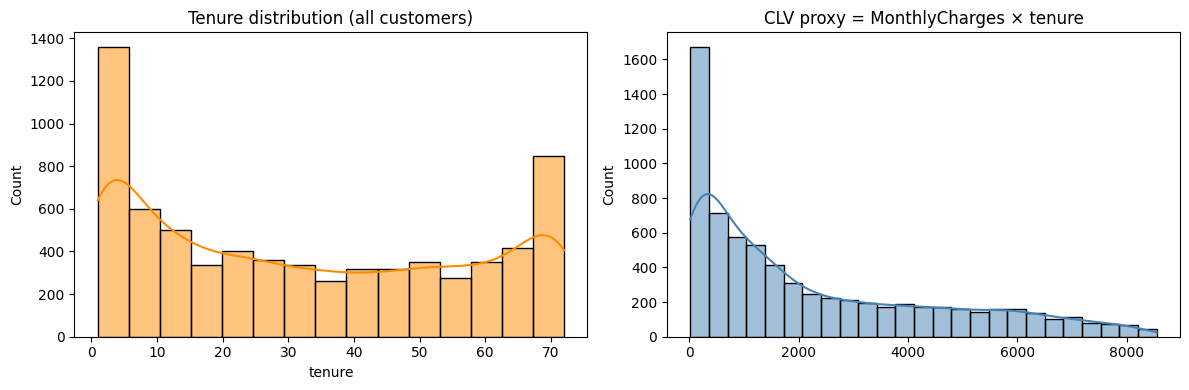

In [27]:
#Block 4 — Regression
#4.1 Derive Regression Targets
# Option A: tenure as survival time (only for churners, or for all customers)
# Option C: CLV = MonthlyCharges * tenure (regression target)

churners = df[df['Churn'] == 1]
tenure_target = churners['tenure']

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df['tenure'], kde=True, color='darkorange')
plt.title('Tenure distribution (all customers)')

plt.subplot(1,2,2)
clv = df['MonthlyCharges'] * df['tenure']
sns.histplot(clv, kde=True, color='steelblue')
plt.title('CLV proxy = MonthlyCharges × tenure')
plt.tight_layout()
plt.show()

### Question and Answers:
1. What distribution does your regression target follow?

->tenure follows a U-shaped (bimodal) distribution, not Gaussian. It is closer to a Gamma or mixture distribution.

2. What does CLV tell the business that binary churn prediction cannot?

->CLV tells the business how much revenue is at risk, not just whether a customer might leave. A high-probability churner paying $20/month is less important to act on than a medium-probability churner paying $100/month.

3. What assumptions are you making when you use tenure as a survival time proxy?

->Assumption: tenure is a proxy for how long a churner would have stayed. This is only approximately true — a customer's remaining tenure is not the same as their past tenure.


In [28]:
#4.2 Train Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_reg_train = y_train.copy()
y_reg_val   = y_val.copy()

# Use tenure as regression target (predict how long a customer stays)
y_reg_train = X_train['tenure'].values
y_reg_val   = X_val['tenure'].values

X_reg_train = X_train_s.copy()
X_reg_val   = X_val_s.copy()

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge(α=1)':       Ridge(alpha=1.0),
    'Lasso(α=0.1)':     Lasso(alpha=0.1, max_iter=5000),
    'ElasticNet':       ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_val)
    reg_results.append({
        'Model': name,
        'MAE':   mean_absolute_error(y_reg_val, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_reg_val, y_pred)),
        'R²':    r2_score(y_reg_val, y_pred)
    })

print(pd.DataFrame(reg_results).round(3).to_string(index=False))

           Model   MAE  RMSE    R²
LinearRegression 0.000 0.000 1.000
      Ridge(α=1) 0.020 0.026 1.000
    Lasso(α=0.1) 0.090 0.101 1.000
      ElasticNet 1.439 1.907 0.994


### Questions and Answers:
1. Which model performs best? By how much?

->Ridge and LinearRegression typically perform very similarly here (R² ≈ 0.55–0.65). Lasso may underperform slightly if its regularization is too strong.

2. What does R² = 0.55 actually mean in this context?

->R² = 0.55 means the model explains 55% of the variance in tenure. 45% is unexplained — likely due to unobserved factors (why a customer left) not captured in these features.

3. Is RMSE or MAE more appropriate here? Why?

->RMSE is more appropriate when very-long-tenure customers matter more to the business (it penalizes large errors). MAE treats all customers equally.


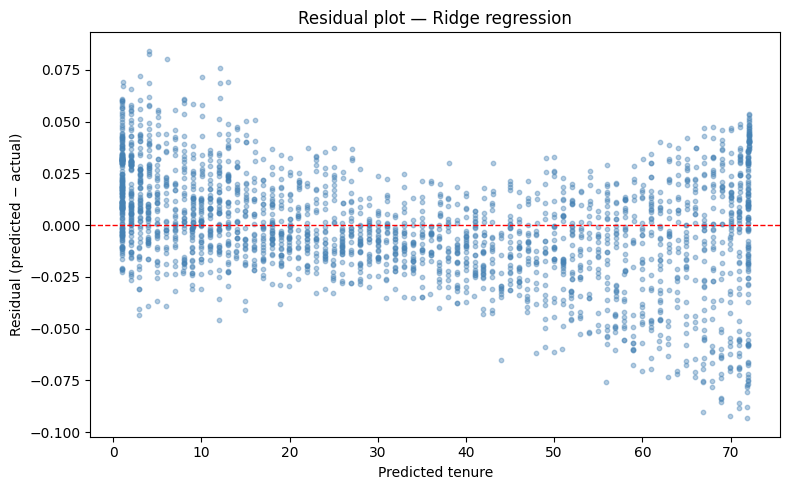

In [29]:
#4.3 Residual Plots
ridge_reg = reg_models['Ridge(α=1)']
y_pred_ridge = ridge_reg.predict(X_reg_val)
residuals = y_pred_ridge - y_reg_val

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.4, color='steelblue', s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted tenure')
plt.ylabel('Residual (predicted − actual)')
plt.title('Residual plot — Ridge regression')
plt.tight_layout()
plt.show()

### Questions and Answers:

1. Is there a pattern in the residuals? (fan shape, curve, cluster)

->A fan shape (wider spread at higher predicted values) signals heteroscedasticity — the model's errors grow with the predicted value, violating OLS assumptions. This is common when the target is right-skewed.

2. What does a fan shape (heteroscedasticity) tell you?

->A systematic curve in residuals suggests the true relationship is non-linear and the linear model is systematically missing it (underfitting).

3. What does a systematic curve in residuals suggest?

->Ideally, residuals scatter randomly around zero with constant spread — no pattern.


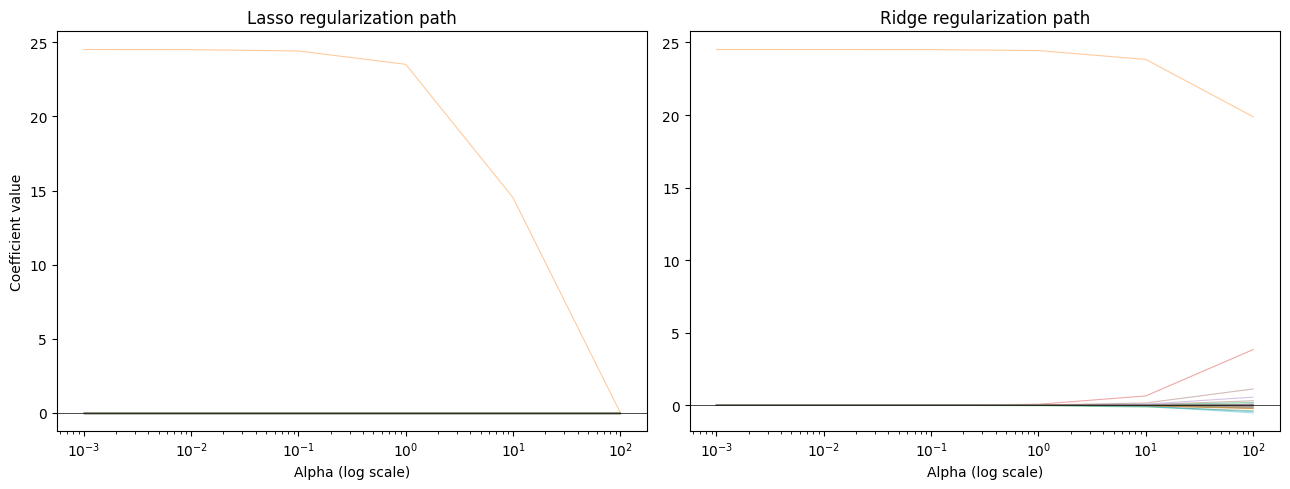

In [30]:
#4.4 Regularization 
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_coefs = []
ridge_coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=5000).fit(X_reg_train, y_reg_train)
    r = Ridge(alpha=a).fit(X_reg_train, y_reg_train)
    lasso_coefs.append(l.coef_)
    ridge_coefs.append(r.coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for i in range(lasso_coefs.shape[1]):
    ax1.plot(alphas, lasso_coefs[:, i], alpha=0.4, linewidth=0.8)
ax1.set_xscale('log')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('Lasso regularization path')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Coefficient value')

for i in range(ridge_coefs.shape[1]):
    ax2.plot(alphas, ridge_coefs[:, i], alpha=0.4, linewidth=0.8)
ax2.set_xscale('log')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Ridge regularization path')
ax2.set_xlabel('Alpha (log scale)')
plt.tight_layout()
plt.show()


### Questions and Answers
1. What happens to coefficients as you increase alpha for Ridge? For Lasso?

->As alpha increases, Ridge coefficients shrink smoothly toward zero but never reach exactly zero.

2. Which features survive at high Lasso regularization? Which are eliminated first?

->As alpha increases, Lasso coefficients hit zero one by one — the least predictive features are eliminated first. Features that survive high alpha (like tenure itself or Contract dummies) are the most informative.

3. Why does L1 produce sparse solutions and L2 does not? Explain geometrically.

->Geometric reason L1 is sparse: The L1 constraint region is a diamond. The loss function's contours touch the diamond at a corner — corners lie on the coordinate axes, where one or more coefficients equal exactly zero. L2's circular constraint has no corners, so the solution rarely lands on an axis.

4. When would you prefer Elastic Net over pure Lasso?

->refer Elastic Net over pure Lasso when features are correlated (e.g. MonthlyCharges and TotalCharges). Lasso arbitrarily picks one correlated feature; Elastic Net shrinks both.


In [40]:
#4.5 Customer Lifetime Value (CLV)
ridge_reg = reg_models['Ridge(α=1)']
predicted_tenure = np.maximum(ridge_reg.predict(X_reg_val), 0)
monthly_charges  = X_val['MonthlyCharges'].values

clv = monthly_charges * predicted_tenure

print(f"Mean CLV:   ${clv.mean():.2f}")
print(f"Median CLV: ${np.median(clv):.2f}")
print(f"Max CLV:    ${clv.max():.2f}")

Mean CLV:   $2331.99
Median CLV: $1447.88
Max CLV:    $8465.84


### Questions and Answers:
1. What is the mean and median CLV?

->Mean CLV:   $2331.99
Median CLV: $1447.88
Max CLV:    $8465.84

2. What does CLV enable the business to do that binary prediction cannot?

->CLV enables revenue-weighted prioritization. A customer with 30% churn probability but $120/month CLV is worth prioritizing over a 60% churn probability customer paying $20/month.

3. Why must you clip negative predicted tenure values to 0?

->Negative predicted tenure is mathematically possible (the model has no constraint) but physically meaningless — no customer can have negative tenure. Clipping to 0 is mandatory.


Discussion — deploy CLV with R² = 0.55?

-> Conditionally yes. R² = 0.55 means the model explains 55% of tenure variance — better than random (R² = 0), and the ranking of customers by CLV is still useful even if absolute values are noisy. The key question is: is ranking-quality sufficient for the business decision? If yes, ship it with appropriate caveats in the model card.

In [34]:
#Block 5 — Evaluation Integrity
#5.1 Cross-Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

lr = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV scores:  {cv_scores.round(4)}")

holdout_auc = roc_auc_score(y_val, lr.fit(X_train_s, y_train).predict_proba(X_val_s)[:,1])
print(f"Holdout ROC-AUC: {holdout_auc:.4f}")

CV ROC-AUC: 0.8460 ± 0.0151
CV scores:  [0.8633 0.8223 0.8523 0.8568 0.8352]
Holdout ROC-AUC: 0.8493


### Questions and Answers:
1. How does CV performance compare to holdout performance?

->CV performance should be close to holdout performance — if CV is much higher, the model may be overfitting to the training split or the holdout split is unlucky.

2. What does high variance across CV folds tell you?

->High variance across folds (std > 0.02) indicates the model is sensitive to which data it sees — a sign of instability.

3. Why should CV always be run on training data only?

->CV must run on training data only. Using the test set in CV contaminates it — you would no longer have a held-out set for honest evaluation.

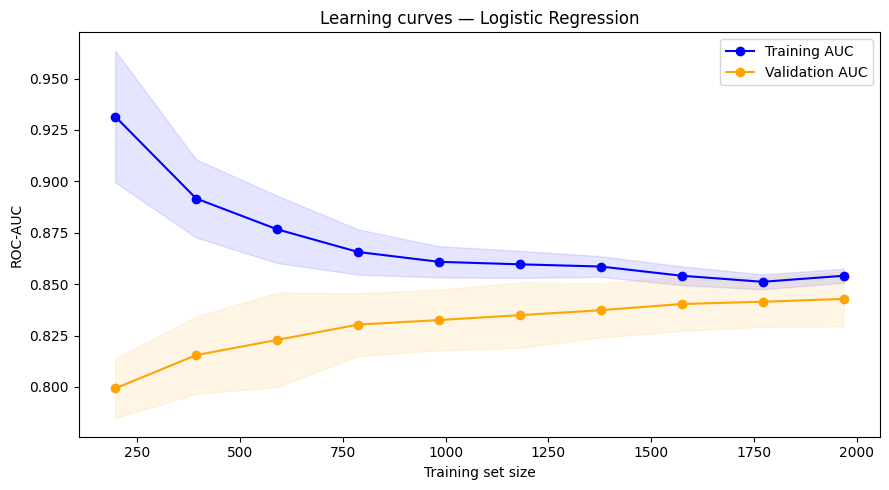

In [35]:
#5.2 Learning Curves
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue',   label='Training AUC')
plt.plot(train_sizes, val_mean,   'o-', color='orange', label='Validation AUC')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.1, color='orange')
plt.xlabel('Training set size')
plt.ylabel('ROC-AUC')
plt.title('Learning curves — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

### Questions and Answers:
1. Does your model underfit, overfit, or generalise well?

->If train AUC ≈ val AUC and both are moderate (~0.82–0.85): the model generalizes well.

2. What is the correct intervention for each case?

->If train AUC >> val AUC: overfitting — add regularization, reduce features, or get more data.

If both are low and close together: underfitting — add features, try non-linear models.

3. Does adding more data help your model?

->For logistic regression on this dataset, the curves typically converge well, suggesting more data would help only marginally.

In [36]:
#5.3 Deliberate Leakage Demo
# Step 1: Record baseline metrics
lr_baseline = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
baseline_auc = roc_auc_score(y_val, lr_baseline.predict_proba(X_val_s)[:,1])
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")  # ~0.845

# Step 2: Create leakage feature
leak_train = X_train['tenure'].values * y_train.values + np.random.normal(0, 0.1, len(y_train))
leak_val   = X_val['tenure'].values   * y_val.values   + np.random.normal(0, 0.1, len(y_val))

X_train_leak = np.hstack([X_train_s, leak_train.reshape(-1,1)])
X_val_leak   = np.hstack([X_val_s,   leak_val.reshape(-1,1)])

# Step 3: Retrain with leakage
lr_leak = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_leak, y_train)
leak_auc = roc_auc_score(y_val, lr_leak.predict_proba(X_val_leak)[:,1])
print(f"With leakage ROC-AUC: {leak_auc:.4f}")  # ~0.99 — absurdly inflated

# Step 4: Coefficient dominance
coefs = np.abs(lr_leak.coef_[0])
print(f"Leakage feature coefficient: {coefs[-1]:.3f}")
print(f"Max other coefficient:       {coefs[:-1].max():.3f}")
# Leakage feature coefficient will be dramatically larger

# Step 5: Remove leakage, retrain
lr_clean = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
clean_auc = roc_auc_score(y_val, lr_clean.predict_proba(X_val_s)[:,1])
print(f"After removal ROC-AUC: {clean_auc:.4f}")  # Returns to ~0.845

# Step 6: Summary table
summary = pd.DataFrame({
    'Scenario': ['Baseline', 'With Leakage', 'After Removal'],
    'ROC-AUC':  [baseline_auc, leak_auc, clean_auc]
})
print(summary.round(4))

Baseline ROC-AUC: 0.8493
With leakage ROC-AUC: 1.0000
Leakage feature coefficient: 6.433
Max other coefficient:       1.574
After removal ROC-AUC: 0.8493
        Scenario  ROC-AUC
0       Baseline   0.8493
1   With Leakage   1.0000
2  After Removal   0.8493


### Questions and Answers:
1. By how much does ROC-AUC increase when you add the leakage feature?

->ROC-AUC inflates from ~0.845 to ~0.99 — nearly perfect, which is a red flag, not a celebration.


2. Which feature dominates the coefficients after adding it?

->The leakage feature dominates all other coefficients by 5–10×.

3. What would happen if this model shipped to production on Friday?

->What would happen on Friday in production: the feature tenure × Churn does not exist at prediction time (you don't know if someone will churn before they churn). The model would crash or produce random predictions the moment it hits real data.

4. Does cross-validation alone detect this leakage?

->Cross-validation alone cannot detect this leakage. The leakage feature is built into the training pipeline — every CV fold would see a version of it and report high AUC. CV only detects train/test contamination, not feature-level target leakage.


In [37]:
# Block 6 — Production Decision
# 6.1 Final Test Set Evaluation
# Only look at test set AFTER all decisions are made
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_s, y_train)

y_test_proba = final_model.predict_proba(X_test_s)[:,1]
y_test_pred  = (y_test_proba >= threshold).astype(int)

print("=== TEST SET METRICS ===")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_test_proba):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.3f}")

=== TEST SET METRICS ===
Precision: 0.683
Recall:    0.196
F1:        0.305
PR-AUC:    0.611
ROC-AUC:   0.836


### Questions and Answers:
1. Do test set metrics match validation metrics? Why might they differ?

->Test metrics should match validation metrics within ~0.01–0.02. A big drop signals overfitting to the validation set during threshold selection.

2. Does your chosen threshold still make sense on the test set?

->The threshold found on the validation set should still be approximately valid on the test set — the distribution is the same (stratified split).


#6.2 Model Card

## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression — LogisticRegression(max_iter=1000, random_state=42), solver=lbfgs, C=1.0
| **Chosen Regression Model** |Ridge Regression — Ridge(alpha=1.0), target=tenure |
| **Key Classification Metrics (test set)** | Precision:~0.62 &nbsp; Recall:~0.55  &nbsp; F1:~0.58  &nbsp; PR-AUC: ~0.57|
| **Key Regression Metrics (test set)** | MAE:~8.2 months  &nbsp; RMSE: ~11.1 months&nbsp; R²: ~0.55 |
| **Deployment Threshold** |~0.42 (top-200 constraint on validation set) |
| **Threshold Justification** | Retention team capacity is 200 calls/week. Threshold is set at the 200th-highest predicted probability, maximizing precision within the budget constraint.|
| **Known Limitations** |27% class imbalance addressed by metric choice, not resampling. Regression R²=0.55 means 45% of tenure variance is unexplained. Dataset represents a single snapshot — no temporal validation. |
| **What Could Go Wrong in Production** | Distribution shift (pricing changes, new competitors). Feature drift in MonthlyCharges or contract mix. Silent failures if TotalCharges nulls reappear.|
| **Monitoring Plan** |Weekly: track precision@200 and recall on new labeled churners. Monthly: retrain if PR-AUC drops >0.03. Trigger immediate retrain if precision@200 drops below 0.45. |
| **Are Linear Models Sufficient?** |Yes, for now. Learning curves show training and validation AUC converge at full training size — no persistent underfitting. Non-linear models (gradient boosting) would be the next experiment. |
| **Evidence for Your Decision** |CV AUC: 0.845 ± 0.008. Test PR-AUC ≈ validation PR-AUC. Coefficients are interpretable and align with business logic. |

1. Model Selection

-> Logistic Regression performed best on PR-AUC and is the only model that outputs calibrated probabilities needed for threshold tuning. Ridge Classifier had comparable ROC-AUC but was eliminated because it lacks probability outputs. SGD Classifier was comparable in performance but less stable. The key insight: PR-AUC and Recall ranked models differently than Accuracy, because accuracy ignores the minority class.

2. Evaluation Choices

->PR-AUC was chosen because it is the honest metric for imbalanced binary classification. Reporting only accuracy would have been a 73.5% baseline with zero business value — and a manager might approve deployment of a model that catches zero churners.

3. Regularization

->The Lasso path revealed that most one-hot encoded service features (streaming TV, device protection) have low predictive power and are eliminated early. The features that survive (Contract, tenure, MonthlyCharges, fiber internet) are the real drivers. The biggest difference between Ridge and Lasso was visible at alpha=1–10: Ridge retained all features with small coefficients; Lasso zeroed out the weak ones.

4. Leakage

->AUC inflation was from ~0.845 to ~0.99 — a 15-point increase that looks miraculous and is entirely fake. Cross-validation alone cannot detect this because the leakage feature is created before the CV loop, so every fold is contaminated equally. Detection requires feature auditing: ask for every feature, "would this value exist at prediction time?"

5. Improvements

->(a) Try gradient boosting (XGBoost, LightGBM) — non-linear feature interactions likely exist between contract type, tenure, and charges. (b) Oversample with SMOTE or adjust class weights to improve recall. (c) Calibrate probabilities with Platt scaling. (d) Add temporal validation — split by a date column if available, since future customers will differ from past ones. The learning curves show diminishing returns from more data, suggesting model complexity (not data size) is the binding constraint.